# Support Vector Classification

## Introduction to Support Vector Machines

A **Support Vector Machine (SVM)** is a binary classifier that finds the decision boundary which **maximizes the margin** between the two classes. The few training points that sit closest to the boundary — the *support vectors* — are the only ones that influence the solution; all other training points can be removed without changing the model.

**Connection to Exercise 1.** The SVM is most conveniently solved in its *dual form*. As with kernelized least squares, predictions depend only on kernel evaluations $k(\mathbf{x}_n, \mathbf{x})$ between the query point and the support vectors. Any valid kernel (linear, RBF, string kernel, ...) can be plugged in directly.

**Why the dual form?**
- It naturally incorporates the kernel trick — we never have to compute features explicitly.
- The constraints become a simple box $0 \leq a_n \leq C$ together with one linear equality.
- The solution is *sparse*: only the support vectors have $a_n > 0$.

**This notebook covers:**
1. A warm-up with `scipy.optimize.minimize` for constrained optimization
2. Two kernel functions with a *matrix* interface (linear and RBF)
3. Implementing the C-SVM by solving the dual problem with `scipy`
4. Classifying a linearly separable dataset (linear kernel)
5. Classifying a non-linearly separable dataset (RBF kernel)

In [35]:
## Imports and helper functions
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

from scipy.optimize import minimize
from sklearn.datasets import make_circles, make_blobs

def get_simple():
    X, y = make_blobs(centers=[[-1.5, -1.5], [1.5, 1.5]], n_samples=100, random_state=42)
    y[y == 0] = -1
    return X, y

def get_difficult():
    X, y = make_circles(n_samples=200, noise=0.2, factor=0.5, random_state=42)
    y[y == 0] = -1
    return X, y

def make_meshgrid(x, y, h=.02):
    x_min, x_max = np.min(x) - 0.1 * np.abs(np.min(x)), np.max(x) + 0.1 * np.abs(np.max(x))
    y_min, y_max = np.min(y) - 0.1 * np.abs(np.min(y)), np.max(y) + 0.1 * np.abs(np.max(y))
    xx, yy = np.mgrid[x_min:x_max:h, y_min:y_max:h]
    return xx, yy

def plot_contours(ax, svm, xx, yy, **params):
    X_mesh = np.c_[xx.ravel(), yy.ravel()]
    Z = svm.decision_function(X_mesh).reshape(xx.shape)
    ax.contourf(xx, yy, Z, **params)
    ax.contour(xx, yy, Z, [-.1, .1], vmin=-.012, vmax=.012, linewidths=[2, 2])

## Warm-up: Constrained Optimization with `scipy.optimize.minimize`

Before we implement the SVM we get familiar with the optimizer that does the heavy lifting. `scipy.optimize.minimize` solves
$$\min_{\mathbf{x}}\; f(\mathbf{x}) \quad \text{subject to constraints on } \mathbf{x}.$$

The arguments we will use repeatedly:

| Argument         | Purpose                                                                       |
|------------------|--------------------------------------------------------------------------------|
| `fun`            | The objective function $f(\mathbf{x})$.                                        |
| `x0`             | Initial guess for $\mathbf{x}$.                                                |
| `method='SLSQP'` | Sequential Least Squares Programming — handles equality and inequality constraints. |
| `constraints`    | List of dicts. Each dict has a `'type'` (`'eq'` or `'ineq'`) and a `'fun'`.    |

**Constraint convention used by SLSQP:**
- `'eq'`: the constraint function must equal **zero**, i.e. $g(\mathbf{x}) = 0$.
- `'ineq'`: the constraint function must be **non-negative**, i.e. $g(\mathbf{x}) \geq 0$.

This is exactly the form we need for the SVM dual:
- The equality $\sum_n a_n t_n = 0$ becomes `{'type': 'eq', 'fun': lambda a: a @ t}`.
- The box constraint $0 \leq a_n \leq C$ becomes the pair
  `{'type': 'ineq', 'fun': lambda a: a}` (i.e. $a_n \geq 0$) and
  `{'type': 'ineq', 'fun': lambda a: C - a}` (i.e. $C - a_n \geq 0$).

### Example 1: Unconstrained minimization

We start with a function that has a known analytical minimum to make sure the API is clear:
$$\min_{x, y}\; (x - 3)^2 + (y + 1)^2$$
The minimum is at $(x^*, y^*) = (3, -1)$ with $f(x^*, y^*) = 0$.

In [36]:
# Example 1: a simple unconstrained quadratic
result = minimize(
    fun=lambda z: (z[0] - 3)**2 + (z[1] + 1)**2,
    x0=[0.0, 0.0],
)
print(f'Solution:        x* = {result.x}')      # [3., -1.]
print(f'Function value:  f* = {result.fun:.4g}') # ~0.0

Solution:        x* = [ 3.00000004 -1.00000007]
Function value:  f* = 7.037e-15


### Example 2: An equality constraint — closest point on a line

We now look for the point on the line $x + 2y = 1$ that is closest to the origin:
$$\min_{x, y}\; x^2 + y^2 \quad \text{subject to}\quad x + 2y - 1 = 0.$$
The analytical solution (the orthogonal projection of the origin onto the line) is $(x^*, y^*) = (\tfrac{1}{5}, \tfrac{2}{5})$.

**How is the constraint written?** SLSQP expects an `'eq'` constraint to evaluate to zero, so we rewrite $x + 2y = 1$ as $x + 2y - 1 = 0$ and pass it as a `lambda`.

Solution:           x* = [0.2 0.4]
Constraint check:   x + 2y - 1 = 0.00e+00


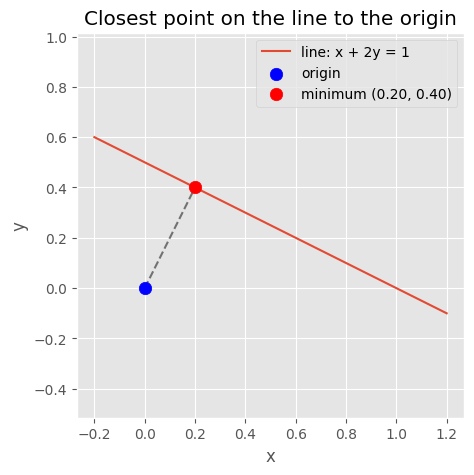

In [37]:
# Example 2: equality-constrained minimization
result = minimize(
    fun=lambda z: z[0]**2 + z[1]**2,
    x0=[0.5, 0.5],
    constraints=[{'type': 'eq', 'fun': lambda z: z[0] + 2*z[1] - 1}],
    method='SLSQP',
)
print(f'Solution:           x* = {result.x}')                       # [0.2, 0.4]
print(f'Constraint check:   x + 2y - 1 = {result.x[0] + 2*result.x[1] - 1:.2e}')

# Quick visualization
t = np.linspace(-0.2, 1.2, 50)
plt.figure(figsize=(5, 5))
plt.plot(t, (1 - t) / 2, label='line: x + 2y = 1')
plt.scatter(0, 0, color='blue', s=80, zorder=5, label='origin')
plt.scatter(*result.x, color='red', s=80, zorder=5, label=f'minimum ({result.x[0]:.2f}, {result.x[1]:.2f})')
plt.plot([0, result.x[0]], [0, result.x[1]], 'k--', alpha=0.5)
plt.axis('equal')
plt.xlabel('x'); plt.ylabel('y')
plt.legend()
plt.title('Closest point on the line to the origin')
plt.show()

### Example 3: Equality **and** inequality constraints — a mini SVM dual

The SVM dual problem combines a single equality constraint with box constraints on every variable. Here is a tiny problem with exactly the same structure:
$$\min_{x, y}\; x^2 + y^2 \quad \text{subject to}\quad x + y = 1,\; 0 \leq x \leq 0.3,\; 0 \leq y \leq 1.$$
Without bounds the unique minimizer would be $x = y = 0.5$, but the upper bound on $x$ forces the optimizer to a *corner* of the feasible set: $(x^*, y^*) = (0.3, 0.7)$.

This is exactly what happens in the C-SVM when a training point has $a_n^{*} = C$ — the box constraint is *active*.

In [38]:
# Example 3: combining one equality and four inequality constraints
C_demo = 0.3   # upper bound on x

constraints = [
    {'type': 'eq',   'fun': lambda z: z[0] + z[1] - 1},   # x + y = 1
    {'type': 'ineq', 'fun': lambda z: z[0]},              # x >= 0
    {'type': 'ineq', 'fun': lambda z: C_demo - z[0]},     # x <= C_demo  (C_demo - x >= 0)
    {'type': 'ineq', 'fun': lambda z: z[1]},              # y >= 0
    {'type': 'ineq', 'fun': lambda z: 1 - z[1]},          # y <= 1
]

result = minimize(
    fun=lambda z: z[0]**2 + z[1]**2,
    x0=[0.5, 0.5],
    constraints=constraints,
    method='SLSQP',
)
print(f'Solution: x* = {result.x}')   # ~[0.3, 0.7]
print(f'The bound on x is active:   x* = {result.x[0]:.3f}  (upper bound = {C_demo})')

Solution: x* = [0.3 0.7]
The bound on x is active:   x* = 0.300  (upper bound = 0.3)


## Training an SVM via Constrained Optimization

We are now ready for the real thing. Throughout this notebook, $\mathbf{X} \in \mathbb{R}^{N \times D}$ is the matrix of training inputs and $\mathbf{t} \in \{-1, +1\}^N$ the vector of binary labels.

#### Symbol glossary

| Symbol                                  | Meaning                                                                  |
|-----------------------------------------|---------------------------------------------------------------------------|
| $\mathbf{K} \in \mathbb{R}^{N\times N}$ | Kernel (Gram) matrix, $K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$.          |
| $\mathbf{T} = \mathrm{diag}(\mathbf{t})$| Diagonal matrix of labels.                                               |
| $\mathbf{a} \in \mathbb{R}^N$           | Dual variables (one per training point).                                 |
| $C > 0$                                 | Regularization parameter; upper bound on each $a_n$.                     |
| $b \in \mathbb{R}$                      | Bias (intercept) of the decision boundary.                               |
| $\mathcal{S}$                           | Set of support vectors ($a_n > 0$).                                      |
| $\mathcal{M}$                           | Margin support vectors ($0 < a_n < C$, lying *on* the margin).           |

#### The dual problem (Bishop Sec. 7.1)
The dual SVM objective is
\begin{align*}
\widetilde{L}(\mathbf{a}) = \sum_{n=1}^N a_n - \frac{1}{2}\sum_{n=1}^N \sum_{m=1}^N a_n a_m t_n t_m k(\mathbf{x}_n, \mathbf{x}_m),
\end{align*}
which, written in matrix form, becomes
$$\widetilde{L}(\mathbf{a}) = \mathbf{1}_N^\top \mathbf{a} - \tfrac{1}{2}\,\mathbf{a}^\top\, \mathbf{T}\mathbf{K}\mathbf{T}\, \mathbf{a}.$$
We **maximize** this subject to
$$0 \leq a_n \leq C, \qquad \sum_{n=1}^N a_n t_n = 0.$$
Since `scipy.optimize.minimize` *minimizes*, we feed it the negative of $\widetilde{L}$.

#### From the optimal $\mathbf{a}$ to predictions
After optimization we identify
- *Support vectors* $\mathcal{S} = \{n : a_n > 0\}$ and
- *Margin support vectors* $\mathcal{M} = \{n : 0 < a_n < C\}$.

The bias is obtained by averaging over the margin support vectors:
$$b = \frac{1}{|\mathcal{M}|}\sum_{n \in \mathcal{M}}\!\left(t_n - \sum_{m \in \mathcal{S}} a_m t_m\, k(\mathbf{x}_n, \mathbf{x}_m)\right).$$
The decision function is then
$$d(\mathbf{x}) = \sum_{n \in \mathcal{S}} a_n t_n\, k(\mathbf{x}_n, \mathbf{x}) + b, \qquad \hat{t}(\mathbf{x}) = \mathrm{sign}(d(\mathbf{x})).$$

### Kernel functions with a matrix interface

The kernels here behave a little differently from Exercises 1 and 2. Instead of taking two single inputs and returning a scalar, they take **two matrices** $\mathbf{X}_1 \in \mathbb{R}^{N\times D}$ and $\mathbf{X}_2 \in \mathbb{R}^{M\times D}$ and return the full **$N \times M$ kernel matrix** in one call:
$$K_{ij} = k(\mathbf{x}^{(1)}_i, \mathbf{x}^{(2)}_j).$$
That avoids a Python `for`-loop over $N \cdot M$ pairs and is the natural interface for SVMs which evaluate the kernel at many points at once.

> Implement the **linear kernel**
> $$k(\mathbf{x}, \mathbf{x}') = \mathbf{x}^\top \mathbf{x}'.$$
> In matrix form this is a single line: $\mathbf{K} = \mathbf{X}_1 \mathbf{X}_2^\top$.

In [39]:
class LinearKernel:
    def __call__(self, X_1, X_2):
        """Linear kernel matrix between X_1 (shape (N, D)) and X_2 (shape (M, D))."""
####################
# Your Code Here   #
####################
        return X_1 @ X_2.T

kernel = LinearKernel()
kernel(np.array([[1, 0], [0, 1]]), np.array([[1, 0], [0, 1]]))  # 2x2 identity

array([[1, 0],
       [0, 1]])

> Implement the **RBF (Gaussian) kernel**
> $$k(\mathbf{x}, \mathbf{x}') = \exp\!\left(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2\right).$$

**Hint — pairwise squared distances with broadcasting.** Given matrices `X_1` of shape `(N, D)` and `X_2` of shape `(M, D)`, we can compute all $N \cdot M$ pairwise squared distances with broadcasting:
```python
diff   = X_1[:, np.newaxis, :] - X_2[np.newaxis, :, :]   # shape (N, M, D)
sq_dist = np.sum(diff**2, axis=-1)                         # shape (N, M)
```
The kernel matrix is then `np.exp(-gamma * sq_dist)`.

**Intuition for $\gamma$.**
- Large $\gamma$: the kernel drops off quickly — only very close points are "similar" — leading to wiggly, possibly overfitting decision boundaries.
- Small $\gamma$: the kernel is broad — even distant points look similar — leading to smooth, possibly underfitting boundaries.

In [40]:
class RBFKernel:
    def __init__(self, gamma=1.0):
        self.gamma = gamma

    def __call__(self, X_1, X_2):
        """RBF kernel matrix between X_1 (shape (N, D)) and X_2 (shape (M, D))."""
        diff   = X_1[:, np.newaxis, :] - X_2[np.newaxis, :, :]
        sq_dist = np.sum(diff**2, axis=-1)  
        return np.exp(-self.gamma * sq_dist)

kernel = RBFKernel(gamma=1.0)
kernel(np.array([[1.0, 0.0]]), np.array([[1.0, 0.0], [0.0, 0.0]]))  # [[1.0, exp(-1)]]

array([[1.        , 0.36787944]])

### The `SVM` class

> Implement the class `SVM` with the following methods:
> - `__init__`: store the kernel function, $C$, and a random seed.
> - `fit(X, t)`: solve the dual problem with `scipy.optimize.minimize`. Identify the support vectors and compute the bias $b$.
> - `decision_function(X)`: evaluate $d(\mathbf{x})$ for every row of `X`.
> - `predict(X)`: return $\mathrm{sign}(d(\mathbf{x}))$ for every row of `X`.

**The recipe** mirrors the warm-up examples above:

1. Compute the Gram matrix $\mathbf{K}$ once with one call to `self.kernel_func(X, X)`.
2. Define the loss as the *negative* dual objective so that `minimize` does the right thing:
   $$\text{loss}(\mathbf{a}) = -\widetilde{L}(\mathbf{a}) = -\mathbf{1}^\top \mathbf{a} + \tfrac{1}{2}\,\mathbf{a}^\top \mathbf{T}\mathbf{K}\mathbf{T}\, \mathbf{a}.$$
3. Build the constraints exactly as in Example 3 — one equality and two inequalities for the box on $\mathbf{a}$.
4. After optimization, snap nearly-zero / nearly-$C$ entries to exact boundaries (this avoids classifying a true zero as a tiny positive support vector due to optimizer noise).
5. Compute $b$ as an average over the *margin* support vectors $\mathcal{M}$.
6. Store only the support vectors — the rest of the training data is no longer needed.

In [41]:
class SVM:
    def __init__(self, kernel_func, C=1.0, random_state=42):
        """C-SVM for binary classification.

        Args:
            kernel_func (callable): A kernel like LinearKernel() or RBFKernel(gamma=...).
            C (float): Regularization parameter, upper bound on each a_n.
            random_state (int): Used to draw the initial a-vector.
        """
####################
# Your Code Here   #
####################
        self.kernel_func = kernel_func
        self.C = C
        self.random_state = random_state

    def fit(self, X, t):
        """Solve the SVM dual problem on training data (X, t)."""
        X, t = np.array(X), np.array(t)
        N = len(X)

        # 1. Pre-compute the Gram matrix once.
        self.gram = self.kernel_func(X, X)

        # 2. Loss = -L(a) so that we can MINIMIZE it with scipy.
        T = np.diag(t)

        def loss(a):
            return -np.sum(a) + 0.5 * (a @ T @ self.gram @ T @ a)


        # 3. Constraints (compare with Example 3 above):
        #    - equality: sum_n a_n t_n = 0
        #    - inequalities: 0 <= a_n <= C  (one constraint for each side)
        constraints = [
                {'type': 'eq',   'fun': lambda z: np.sum(z * t)},   # sum_n a_n t_n = 0
                {'type': 'ineq', 'fun': lambda z: self.C - z},     # a_n <= C
                {'type': 'ineq', 'fun': lambda z: z},              # 0 <= a_n
        ]

        # 4. Run the optimizer with a random starting point.
        a0 = np.random.RandomState(self.random_state).rand(N)
        self.a_ = minimize(loss, a0, constraints=constraints, method='SLSQP').x

        # Numerical cleanup: snap values that are basically 0 or C to exact 0 / C.
        self.a_[np.isclose(self.a_, 0)] = 0
        self.a_[np.isclose(self.a_, self.C)] = self.C

        # 5. Identify the (margin) support vectors.
        self.support_ = np.where((self.a_ > 0) & (self.a_ < self.C))[0]

        # 6. Compute the bias by averaging over margin support vectors.
        self.b_ = np.mean([
                t[n] - np.sum(self.a_ * t * self.gram[:, n])
                for n in self.support_
        ])

        # 7. Keep only the support vectors — everything else can be discarded.
        self.X_ = X[self.support_]
        self.t_ = t[self.support_]
        self.a_ = self.a_[self.support_]


        return self

    def decision_function(self, X):
        """Return d(x) = sum_n a_n t_n k(x_n, x) + b for every row of X."""
        weights = (np.array(self.a_) * np.array(self.t_))[:, np.newaxis]
        K = self.kernel_func(self.X_, X)
        return np.sum(weights * K, axis=0) + self.b_

    def predict(self, X):
        """Predicted class labels in {-1, +1}."""
        return np.sign(self.decision_function(X))

## Classification of a Linearly Separable Dataset

We first check whether our C-SVM with a **linear kernel** can separate a clean linearly separable dataset (two well-separated Gaussian blobs).

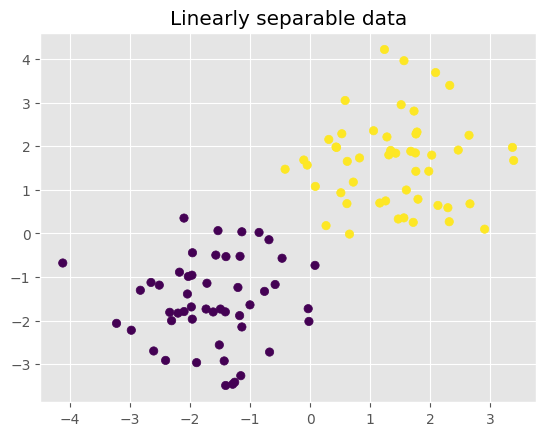

In [42]:
X, y = get_simple()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Linearly separable data')
plt.show()

> Fit an `SVM` with a `LinearKernel` on this data, predict the labels, and visualize the result using `make_meshgrid` and `plot_contours`. Mark the support vectors as larger circles on the plot.

**What to look for:**
- The decision boundary should cleanly separate the two classes.
- The **support vectors** (highlighted in green) sit near the margin — they are the only training points that matter.
- With a large $C$ the margin is narrow, so few points are support vectors.

/var/folders/_1/n85hbfgd2j93hh10__cjmgh40000gn/T/ipykernel_56176/1178595402.py:17: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, Z, levels=[0], colors=[color], linewidths=2, label=f'C={C}')


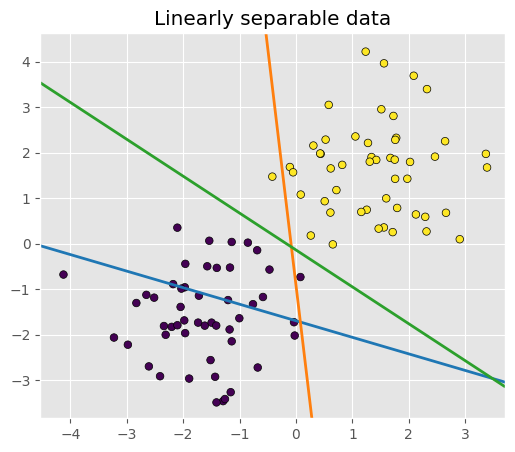

In [43]:
####################
# Your Code Here   #
####################
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors='k')

xx, yy = make_meshgrid(X[:, 0], X[:, 1])
X_mesh = np.c_[xx.ravel(), yy.ravel()]

C_values = [0.1, 1.0, 10.0]
colors = ['tab:blue', 'tab:orange', 'tab:green']

for C, color in zip(C_values, colors):
    svm = SVM(LinearKernel(), C=C)
    svm.fit(X, y)
    Z = svm.decision_function(X_mesh).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0], colors=[color], linewidths=2, label=f'C={C}')

ax.set_title('Linearly separable data')
plt.show()

## Classification of a Non-linearly Separable Dataset

The previous data was easy — the two blobs sat in different regions of feature space. Now we move to a **circular** dataset for which no linear boundary works. This is where the kernel trick really pays off: with an RBF kernel the SVM implicitly lifts the data into a high-dimensional space where the two rings *can* be separated linearly.

**Why does the RBF kernel work here?** For an appropriate $\gamma$, nearby points get high kernel values and distant points are nearly orthogonal in feature space. The inner and outer rings end up in different regions of the implicit feature space, making them separable.

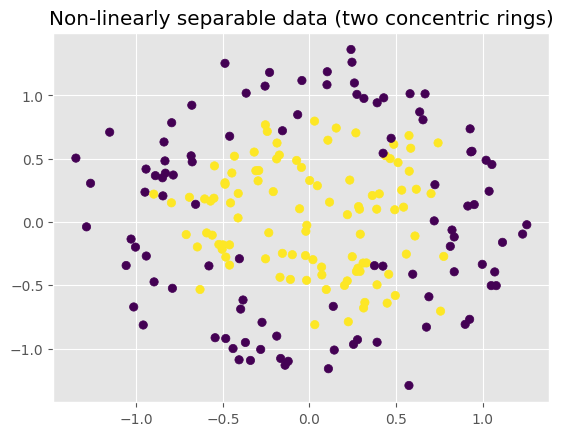

In [44]:
X, y = get_difficult()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Non-linearly separable data (two concentric rings)')
plt.show()

> Now fit an `SVM` with an `RBFKernel` and visualize the result as before. Feel free to experiment with `gamma` and `C`:
>
> | Parameter | Effect when *large*                         |
> |-----------|---------------------------------------------|
> | `gamma`   | Sharper, more local kernel → wigglier boundary; risks overfitting. |
> | `C`       | Few/no margin violations allowed → narrower margin, more support vectors near the boundary. |
>
> Default values of `gamma=1` and a large `C` work well for this dataset.

/Users/stars/Projects/University/PRML2/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/stars/Projects/University/PRML2/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


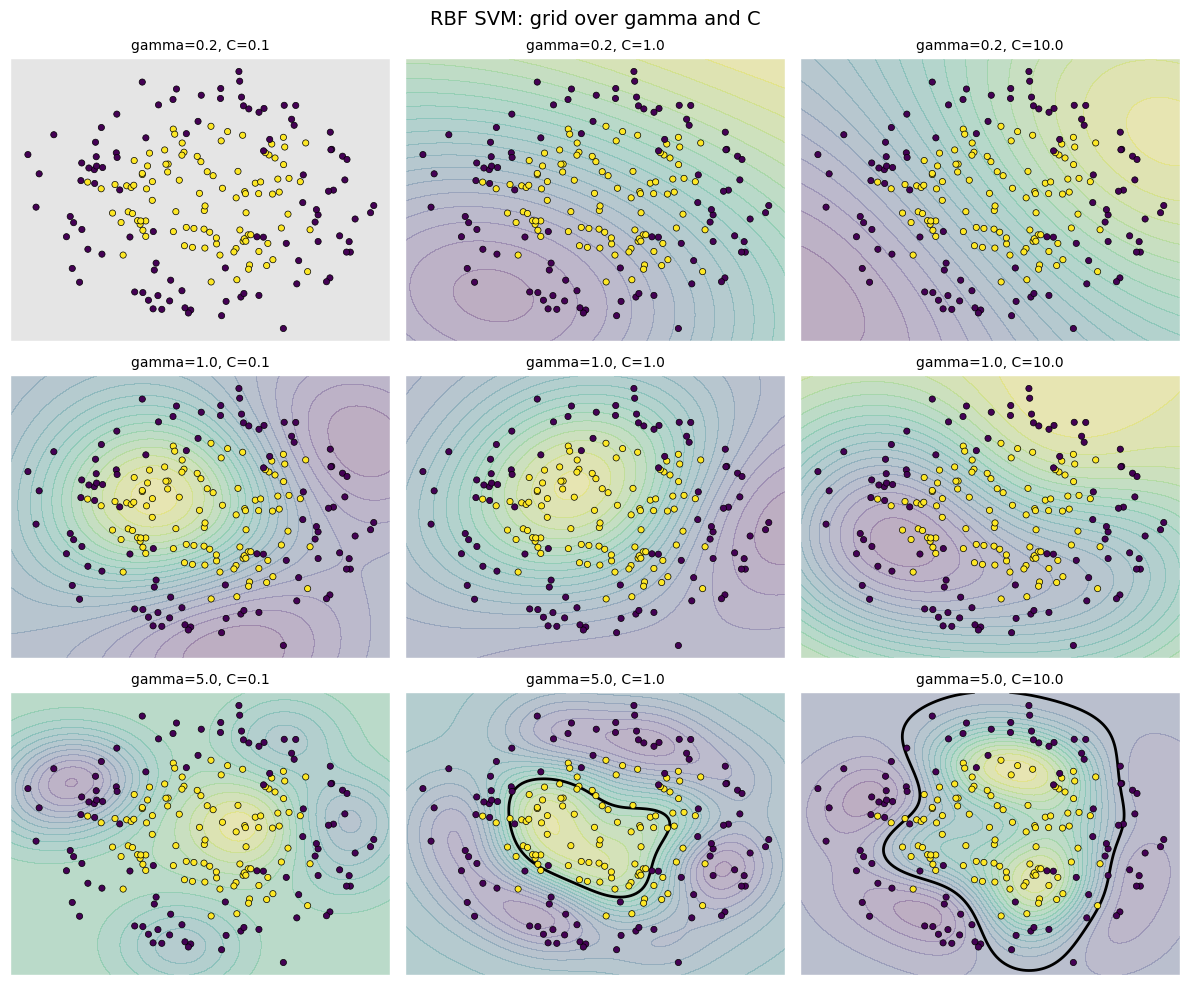

In [45]:
# Compare multiple gamma and C values using subplots
gamma_values = [0.2, 1.0, 5.0]
C_values = [0.1, 1.0, 10.0]

xx, yy = make_meshgrid(X[:, 0], X[:, 1])
X_mesh = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(len(gamma_values), len(C_values), figsize=(12, 10), sharex=True, sharey=True)

for i, gamma in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        ax = axes[i, j]
        svm = SVM(RBFKernel(gamma=gamma), C=C)
        svm.fit(X, y)
        Z = svm.decision_function(X_mesh).reshape(xx.shape)

        ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolors='k', zorder=3)
        ax.contourf(xx, yy, Z, levels=20, alpha=0.25)
        ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=2)

        ax.set_title(f'gamma={gamma}, C={C}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle('RBF SVM: grid over gamma and C', fontsize=14)
plt.tight_layout()
plt.show()